# LSTM-KDE (Fixed) — SWH Forecasting

Uses calibration holdout residuals (not training residuals) for KDE — see SLA analysis for why this matters.

In [1]:
# ── Cell 1: Environment ──────────────────────────────────────
RUN_ENV  = 'local'
BASE_DIR = r'c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes'         # change to your path
if RUN_ENV == 'colab':
    from google.colab import drive; drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/BMP_Data/'

import os, warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.preprocessing import RobustScaler
warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# ── SWH-specific paths (only change from SLA notebooks) ──────
DATA_FILE = os.path.join(BASE_DIR, 'swh_daily_indian_ocean_2021_2023.nc')
SAVE_DIR  = os.path.join(BASE_DIR, 'results_SWH/')
os.makedirs(SAVE_DIR, exist_ok=True)

print(f'TF {tf.__version__} | Env: {RUN_ENV}')
print(f'Data: {DATA_FILE}')
print(f'Save: {SAVE_DIR}')

from sklearn.neighbors import KernelDensity

TF 2.21.0 | Env: local
Data: c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes\swh_daily_indian_ocean_2021_2023.nc
Save: c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes\results_SWH/


Loading SWH dataset...
SWH variable detected: VHM0
Period: 2021-01-01 to 2023-12-31 (1095 days)
Grid: lat=-9.80 to 24.80, lon=50.20 to 100.00

Coverage check at each location:
  Arabian_Sea        (15.0N,65.0E) | NaN=0.0% | range=[0.587, 6.220]m ✓
  Bay_of_Bengal      (12.0N,87.0E) | NaN=0.0% | range=[0.699, 4.966]m ✓
  Andaman_Sea        (11.0N,95.0E) | NaN=0.0% | range=[0.466, 3.289]m ✓
  Lakshadweep        (10.0N,73.0E) | NaN=0.0% | range=[0.651, 4.692]m ✓
  South_IO           (-5.0N,75.0E) | NaN=0.0% | range=[1.046, 4.220]m ✓

NOTE: SWH > 0 always. NaN means ice-covered or land-masked cells.
If NaN > 20% at a location, consider shifting 1-2 degrees offshore.


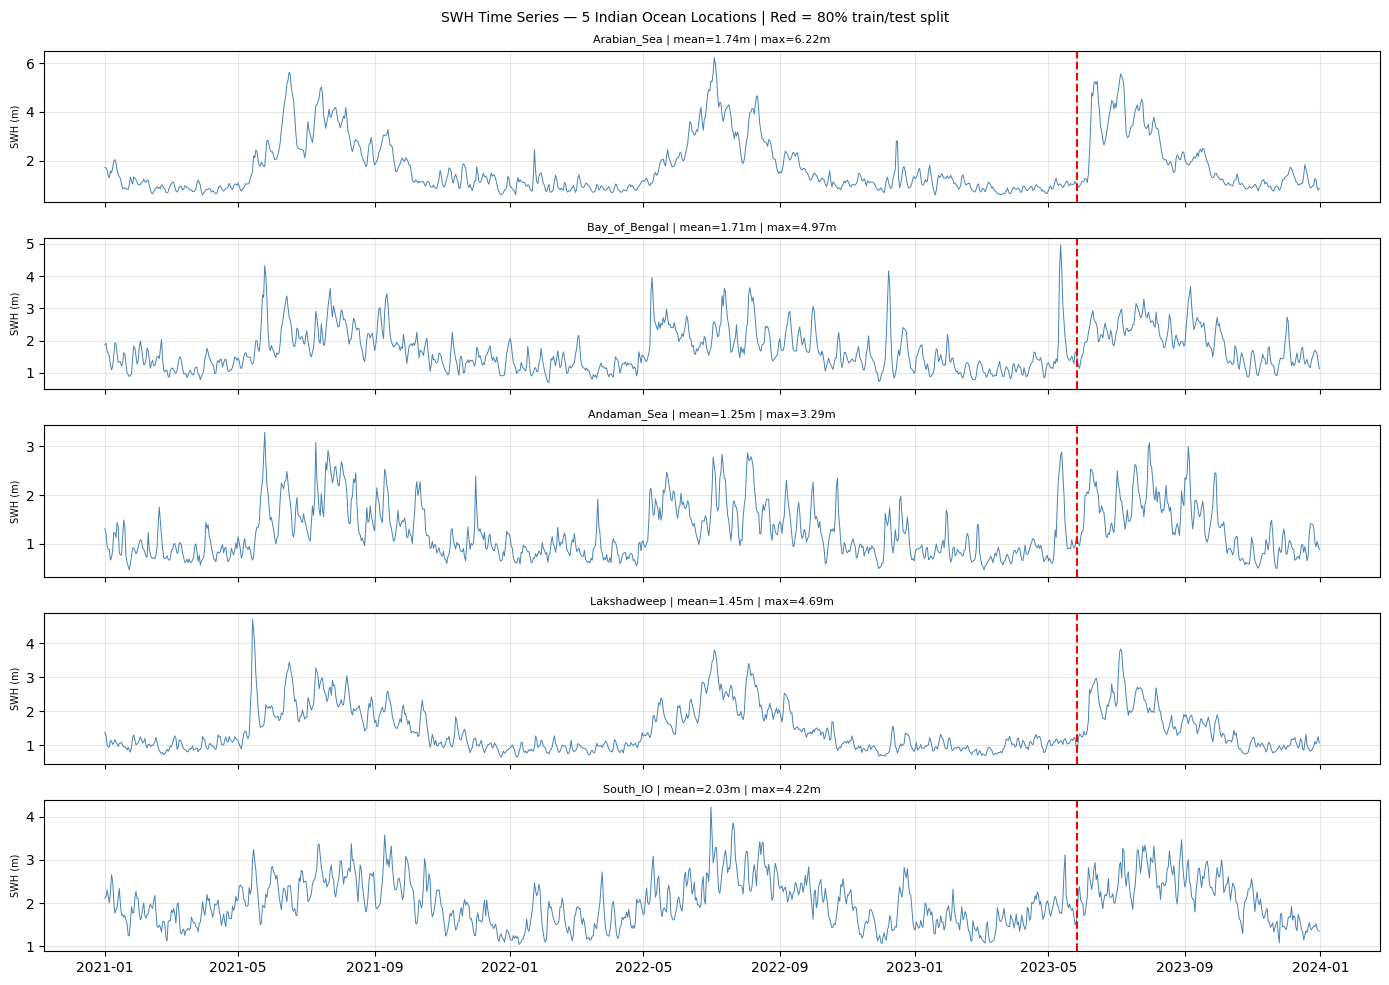

In [2]:
# ── Cell 2: Load SWH Data ────────────────────────────────────
# Same 5 Indian Ocean locations as SLA study (same coordinates,
# same period 2021-2023) — enables direct SLA vs SWH comparison.
LOCATIONS = {
    'Arabian_Sea':   (15.0, 65.0),
    'Bay_of_Bengal': (12.0, 87.0),
    'Andaman_Sea':   (11.0, 95.0),
    'Lakshadweep':   (10.0, 73.0),
    'South_IO':      (-5.0, 75.0),
}

print('Loading SWH dataset...')
ds = xr.open_dataset(DATA_FILE)
ds = ds.resample(time='1D').mean()
times_index = pd.to_datetime(ds['time'].values)

# ── Auto-detect SWH variable name ───────────────────────────
# CMEMS products use different names depending on the product:
# 'VHM0'  → ERA5-based reanalysis / wave model reanalysis
# 'hs'    → some hindcast products
# 'swh'   → alternative naming
SWH_VAR = None
for candidate in ['VHM0', 'hs', 'swh', 'SWH', 'Hs']:
    if candidate in ds.data_vars:
        SWH_VAR = candidate
        break
if SWH_VAR is None:
    print("Available variables:", list(ds.data_vars))
    raise ValueError("Cannot find SWH variable. Set SWH_VAR manually above.")

print(f'SWH variable detected: {SWH_VAR}')
print(f'Period: {times_index[0].date()} to {times_index[-1].date()} ({len(times_index)} days)')
print(f'Grid: lat={float(ds.latitude.min()):.2f} to {float(ds.latitude.max()):.2f}, '
      f'lon={float(ds.longitude.min()):.2f} to {float(ds.longitude.max()):.2f}')

# ── Coverage + NaN check ─────────────────────────────────────
print('\nCoverage check at each location:')
for loc, (lat, lon) in LOCATIONS.items():
    swh = ds[SWH_VAR].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    nan_pct = np.isnan(swh).mean() * 100
    valid   = swh[~np.isnan(swh)]
    rng     = f"[{valid.min():.3f}, {valid.max():.3f}]m" if len(valid) > 0 else "ALL NaN"
    flag    = " ⚠️ HIGH NaN" if nan_pct > 20 else " ✓"
    print(f'  {loc:<18} ({lat:.1f}N,{lon:.1f}E) | NaN={nan_pct:.1f}% | range={rng}{flag}')

print()
print('NOTE: SWH > 0 always. NaN means ice-covered or land-masked cells.')
print('If NaN > 20% at a location, consider shifting 1-2 degrees offshore.')

# ── Quick time series plot ────────────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)
for ax, (loc, (lat, lon)) in zip(axes, LOCATIONS.items()):
    swh = ds[SWH_VAR].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    ax.plot(times_index, swh, lw=0.7, color='steelblue')
    n_train = int(len(swh)*0.80)
    ax.axvline(times_index[n_train], color='red', lw=1.5, ls='--')
    ax.set_title(f'{loc} | mean={np.nanmean(swh):.2f}m | max={np.nanmax(swh):.2f}m', fontsize=8)
    ax.set_ylabel('SWH (m)', fontsize=7); ax.grid(True, alpha=0.3)
fig.suptitle('SWH Time Series — 5 Indian Ocean Locations | Red = 80% train/test split', fontsize=10)
plt.tight_layout(); plt.show()

In [3]:
# ── Cell 3: Config + All Helpers ─────────────────────────────
TRAIN_SPLIT  = 0.80
SEQ_LEN      = 30     # 30-day lookback (same as SLA)
EPOCHS       = 100
BATCH_SIZE   = 64
LR           = 0.001
PATIENCE     = 20
VAL_SPLIT    = 0.10
SEEDS        = [42, 7, 13, 99, 2025]
TUBE_R       = 0.5
TUBE_DELTA   = 0.01
MIN_WIDTH    = 0.05   # ← SWH: 5 cm minimum width (SLA used 0.005 m)
                      #   SWH varies by metres so minimum is larger
DROPOUT      = 0.2
ALPHA_WIS    = 0.20   # p10/p90 intervals
TARGET_PICP  = 0.95

print(f'SEQ_LEN={SEQ_LEN} | EPOCHS={EPOCHS} | BATCH={BATCH_SIZE} | {len(SEEDS)} seeds')
print(f'Tube: r={TUBE_R}, delta={TUBE_DELTA} | MIN_WIDTH={MIN_WIDTH}m (5cm for SWH)')

# ─── Data splits with SWH-specific NaN handling ───────────────
def get_splits(loc_name):
    lat, lon = LOCATIONS[loc_name]
    swh_raw = ds[SWH_VAR].sel(latitude=lat, longitude=lon, method='nearest').values.flatten()
    # Linear interpolation for gaps ≤ 14 days, then forward-fill
    s = pd.Series(swh_raw, index=times_index).interpolate(method='time', limit=14).ffill().bfill()
    # SWH FLOOR: wave height cannot be negative (unlike SLA)
    s = s.clip(lower=0.0)
    data = s.values

    n = len(data); n_train = int(n * TRAIN_SPLIT); n_test = n - n_train
    scaler  = RobustScaler()
    train_s = scaler.fit_transform(data[:n_train].reshape(-1,1)).flatten()
    test_s  = scaler.transform(data[n_train:].reshape(-1,1)).flatten()
    combined = np.concatenate([train_s, test_s])

    X_tr = np.array([train_s[i:i+SEQ_LEN] for i in range(len(train_s)-SEQ_LEN)])[..., np.newaxis]
    y_tr = np.array([train_s[i+SEQ_LEN]   for i in range(len(train_s)-SEQ_LEN)])
    X_te = np.array([combined[n_train-SEQ_LEN+i:n_train+i] for i in range(n_test)])[..., np.newaxis]
    y_te = np.array([combined[n_train+i] for i in range(n_test)])
    return dict(X_tr=X_tr, y_tr=y_tr, X_te=X_te, y_te=y_te,
                scaler=scaler, n_train=n_train, n_test=n_test, raw=data)

# ─── Loss functions (identical to SLA — MIN_WIDTH handles scale) ──
def build_quantile_loss(scaler, q_lo=0.10, q_hi=0.90):
    min_ws = float(abs(scaler.transform([[MIN_WIDTH]])[0][0] - scaler.transform([[0.0]])[0][0]))
    def loss(yt, yp):
        true = yt[:,0:1]; lo = yp[:,0:1]; hi = yp[:,1:2]
        elo, ehi = true-lo, true-hi
        return (tf.reduce_mean(tf.maximum(q_lo*elo,(q_lo-1)*elo))
              + tf.reduce_mean(tf.maximum(q_hi*ehi,(q_hi-1)*ehi))
              + tf.reduce_mean(tf.nn.relu(lo-hi))
              + tf.reduce_mean(tf.nn.relu(min_ws-(hi-lo))))
    return loss

def build_tube_loss(scaler, r=TUBE_R, delta=TUBE_DELTA):
    min_ws = float(abs(scaler.transform([[MIN_WIDTH]])[0][0] - scaler.transform([[0.0]])[0][0]))
    def loss(yt, yp):
        true = yt[:,0:1]; lo = yp[:,0:1]; hi = yp[:,1:2]
        return (tf.reduce_mean((1-r)*tf.nn.relu(lo-true) + r*tf.nn.relu(true-hi)
                + delta*tf.abs(hi-lo) + tf.nn.relu(lo-hi))
              + tf.reduce_mean(tf.nn.relu(min_ws-(hi-lo))))
    return loss

# ─── Evaluation — SWH FLOOR applied after inverse_transform ──
def evaluate(y_true_s, y_pred_raw, scaler):
    lo_m = scaler.inverse_transform(y_pred_raw[:,0:1]).flatten()
    hi_m = scaler.inverse_transform(y_pred_raw[:,1:2]).flatten()
    y_m  = scaler.inverse_transform(y_true_s.reshape(-1,1)).flatten()
    if np.any(np.isnan(lo_m)) or np.any(np.isnan(hi_m)):
        return np.nan, np.nan, np.nan, np.nan, lo_m, hi_m, y_m
    lo = np.maximum(np.minimum(lo_m, hi_m), 0.0)  # swap + floor at 0
    hi = np.maximum(np.maximum(lo_m, hi_m), 0.0)  # SWH cannot be negative
    picp = float(np.mean((y_m >= lo) & (y_m <= hi))) * 100.0
    mpiw = float(np.mean(hi - lo))
    wis  = float(np.mean((hi-lo)+(2/ALPHA_WIS)*np.maximum(0,lo-y_m)+(2/ALPHA_WIS)*np.maximum(0,y_m-hi)))
    cwc  = mpiw if picp/100 >= TARGET_PICP else mpiw*np.exp(-50*(picp/100-TARGET_PICP))
    return picp, mpiw, wis, cwc, lo, hi, y_m

# ─── Model builder ────────────────────────────────────────────
from sklearn.neighbors import KernelDensity

def build_lstm_point(seq_len=SEQ_LEN, dropout=DROPOUT):
    """3-layer stacked LSTM matching sir's SWH reference notebook."""
    inp = keras.Input(shape=(seq_len,1))
    x   = layers.LSTM(128, activation='relu', return_sequences=True)(inp)
    x   = layers.Dropout(0.4)(x)
    x   = layers.LSTM(64, activation='relu', return_sequences=True)(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.LSTM(32, activation='relu', return_sequences=False)(x)
    x   = layers.Dropout(0.2)(x)
    return keras.Model(inp, layers.Dense(1, activation='linear')(x))

def silverman_bw(data):
    n=len(data); std=np.std(data,ddof=1)
    iqr=np.percentile(data,75)-np.percentile(data,25)
    sigma=min(std,iqr/1.349)
    return max(1.06*sigma*n**(-0.2), 1e-5)

def kde_bounds_from_calibration(resid_cal, target=0.95):
    """Fit KDE on HELD-OUT calibration residuals (not training residuals)."""
    h=silverman_bw(resid_cal)
    kde=KernelDensity(bandwidth=h,kernel='gaussian')
    kde.fit(resid_cal.reshape(-1,1))
    xs=np.linspace(resid_cal.min()*3,resid_cal.max()*3,10000)
    dens=np.exp(kde.score_samples(xs.reshape(-1,1))); dens/=dens.sum()
    cdf=np.cumsum(dens)
    best_lo,best_hi=None,None
    for alpha in np.linspace(0.001,0.10,100):
        lo_v=float(xs[np.searchsorted(cdf,alpha)])
        hi_v=float(xs[np.searchsorted(cdf,1-alpha)])
        if float(np.mean((resid_cal>=lo_v)&(resid_cal<=hi_v)))>=target:
            best_lo,best_hi=lo_v,hi_v; break
    if best_lo is None:
        best_lo=float(np.quantile(resid_cal,0.025))
        best_hi=float(np.quantile(resid_cal,0.975))
    return best_lo, best_hi

ARCH = 'LSTM-KDE'

# Override evaluate for KDE (uses lo_m/hi_m already in metres)
def evaluate_kde(y_true_s, lo_m, hi_m, scaler):
    y_m = scaler.inverse_transform(y_true_s.reshape(-1,1)).flatten()
    lo  = np.maximum(np.minimum(lo_m,hi_m), 0.0)   # SWH floor
    hi  = np.maximum(np.maximum(lo_m,hi_m), 0.0)
    picp= float(np.mean((y_m>=lo)&(y_m<=hi)))*100.0
    mpiw= float(np.mean(hi-lo))
    wis = float(np.mean((hi-lo)+(2/ALPHA_WIS)*np.maximum(0,lo-y_m)+(2/ALPHA_WIS)*np.maximum(0,y_m-hi)))
    cwc = mpiw if picp/100>=TARGET_PICP else mpiw*np.exp(-50*(picp/100-TARGET_PICP))
    return picp, mpiw, wis, cwc, lo, hi, y_m

print("LSTM-KDE defined. Using CALIBRATION HOLDOUT residuals (not training residuals).")

print('All helpers defined. Proceed to Cell 4.')

SEQ_LEN=30 | EPOCHS=100 | BATCH=64 | 5 seeds
Tube: r=0.5, delta=0.01 | MIN_WIDTH=0.05m (5cm for SWH)
LSTM-KDE defined. Using CALIBRATION HOLDOUT residuals (not training residuals).
All helpers defined. Proceed to Cell 4.


In [9]:
# Cell 4 — LSTM-KDE Training
CAL_FRAC = 0.20   # 20% of training data as calibration holdout
all_results=[]; all_preds={}

for loc_name in LOCATIONS:
    print(f'\n{"#"*55}')
    print(f'  LSTM-KDE (Fixed) @ {loc_name}')
    print(f'{"#"*55}')
    lat,lon=LOCATIONS[loc_name]
    swh_raw=ds[SWH_VAR].sel(latitude=lat,longitude=lon,method='nearest').values.flatten()
    s=pd.Series(swh_raw,index=times_index).interpolate(method='time',limit=14).ffill().bfill()
    s=s.clip(lower=0); data=s.values
    n=len(data); n_train=int(n*TRAIN_SPLIT); n_test=n-n_train
    n_cal=int(n_train*CAL_FRAC); n_inner=n_train-n_cal

    scaler=RobustScaler()
    inner_s=scaler.fit_transform(data[:n_inner].reshape(-1,1)).flatten()
    cal_s  =scaler.transform(data[n_inner:n_train].reshape(-1,1)).flatten()
    test_s =scaler.transform(data[n_train:].reshape(-1,1)).flatten()
    comb_ic=np.concatenate([inner_s,cal_s])
    comb_full=np.concatenate([scaler.transform(data[:n_train].reshape(-1,1)).flatten(),test_s])

    X_tr=np.array([inner_s[i:i+SEQ_LEN] for i in range(len(inner_s)-SEQ_LEN)])[...,np.newaxis]
    y_tr=np.array([inner_s[i+SEQ_LEN]   for i in range(len(inner_s)-SEQ_LEN)])
    X_cal=np.array([comb_ic[n_inner-SEQ_LEN+i:n_inner+i] for i in range(n_cal)])[...,np.newaxis]
    y_cal=np.array([comb_ic[n_inner+i] for i in range(n_cal)])
    X_te =np.array([comb_full[n_train-SEQ_LEN+i:n_train+i] for i in range(n_test)])[...,np.newaxis]
    y_te =np.array([comb_full[n_train+i] for i in range(n_test)])
    all_preds[loc_name]={'LSTM-KDE':{}}
    s_picps,s_mpiws,s_wis,s_cwc=[],[],[],[]
    print(f'  Inner train: {len(X_tr)} seqs | Cal: {n_cal} pts | Test: {n_test} pts')

    for seed in SEEDS:
        tf.random.set_seed(seed); np.random.seed(seed)
        m=build_lstm_point()
        m.compile(optimizer=keras.optimizers.Adam(LR,clipnorm=1.0),loss='mse')
        cbs=[keras.callbacks.EarlyStopping(patience=PATIENCE,restore_best_weights=True,verbose=0),
             keras.callbacks.ReduceLROnPlateau(factor=0.5,patience=10,min_lr=1e-6,verbose=0)]
        m.fit(X_tr,y_tr,epochs=EPOCHS,batch_size=BATCH_SIZE,
              validation_split=VAL_SPLIT,callbacks=cbs,verbose=0)
        # Calibration residuals (HELD-OUT data)
        mu_cal=m.predict(X_cal,verbose=0).flatten()
        resid_cal=y_cal-mu_cal
        lo_off, hi_off = kde_bounds_from_calibration(resid_cal, target=0.98)
        mu_te=m.predict(X_te,verbose=0).flatten()
        lo_s=mu_te+lo_off; hi_s=mu_te+hi_off
        lo_m=scaler.inverse_transform(lo_s.reshape(-1,1)).flatten()
        hi_m=scaler.inverse_transform(hi_s.reshape(-1,1)).flatten()
        picp,mpiw,wis,cwc,lo,hi,y_m=evaluate_kde(y_te,lo_m,hi_m,scaler)
        s_picps.append(picp);s_mpiws.append(mpiw);s_wis.append(wis);s_cwc.append(cwc)
        all_preds[loc_name]['LSTM-KDE'][seed]=(lo,hi,y_m)
        print(f'    seed={seed:4d} | PICP={picp:.1f}% | MPIW={mpiw:.4f}m')

    avg_p=np.nanmean(s_picps);std_p=np.nanstd(s_picps)
    avg_m=np.nanmean(s_mpiws);std_m=np.nanstd(s_mpiws)
    avg_w=np.nanmean(s_wis);std_w=np.nanstd(s_wis)
    avg_c=np.nanmean(s_cwc);std_c=np.nanstd(s_cwc)
    n_v=sum(1 for p in s_picps if not np.isnan(p))
    print(f'  PICP={avg_p:.1f}+/-{std_p:.1f}%  MPIW={avg_m:.4f}m  WIS={avg_w:.4f}  [{n_v}/{len(SEEDS)}]')
    all_results.append(dict(
        location=loc_name,lat=lat,lon=lon,arch='LSTM-KDE',loss='KDE-Calibration',model='LSTM-KDE',
        avg_picp=avg_p,std_picp=std_p,avg_mpiw=avg_m,std_mpiw=std_m,
        avg_wis=avg_w,std_wis=std_w,avg_cwc=avg_c,std_cwc=std_c,
        n_seeds=len(SEEDS),n_valid_seeds=n_v,cal_frac=CAL_FRAC,
        n_train_seqs=len(X_tr),n_test_pts=n_test,seq_len=SEQ_LEN))

df=pd.DataFrame(all_results)
csv_path=os.path.join(SAVE_DIR,'results_LSTM_KDE_SWH.csv')
df.to_csv(csv_path,index=False)
print(f'\nSaved: {csv_path}')


#######################################################
  LSTM-KDE (Fixed) @ Arabian_Sea
#######################################################
  Inner train: 671 seqs | Cal: 175 pts | Test: 219 pts
    seed=  42 | PICP=98.6% | MPIW=2.4512m
    seed=   7 | PICP=97.7% | MPIW=2.5459m
    seed=  13 | PICP=96.8% | MPIW=2.5322m
    seed=  99 | PICP=98.2% | MPIW=2.7488m
    seed=2025 | PICP=97.3% | MPIW=2.5901m
  PICP=97.7+/-0.6%  MPIW=2.5736m  WIS=2.7575  [5/5]

#######################################################
  LSTM-KDE (Fixed) @ Bay_of_Bengal
#######################################################
  Inner train: 671 seqs | Cal: 175 pts | Test: 219 pts
    seed=  42 | PICP=100.0% | MPIW=3.1428m
    seed=   7 | PICP=100.0% | MPIW=3.0211m
    seed=  13 | PICP=100.0% | MPIW=2.9973m
    seed=  99 | PICP=100.0% | MPIW=3.1080m
    seed=2025 | PICP=100.0% | MPIW=2.9203m
  PICP=100.0+/-0.0%  MPIW=3.0379m  WIS=3.0379  [5/5]

#######################################################
  LSTM-KD

Generating plots...


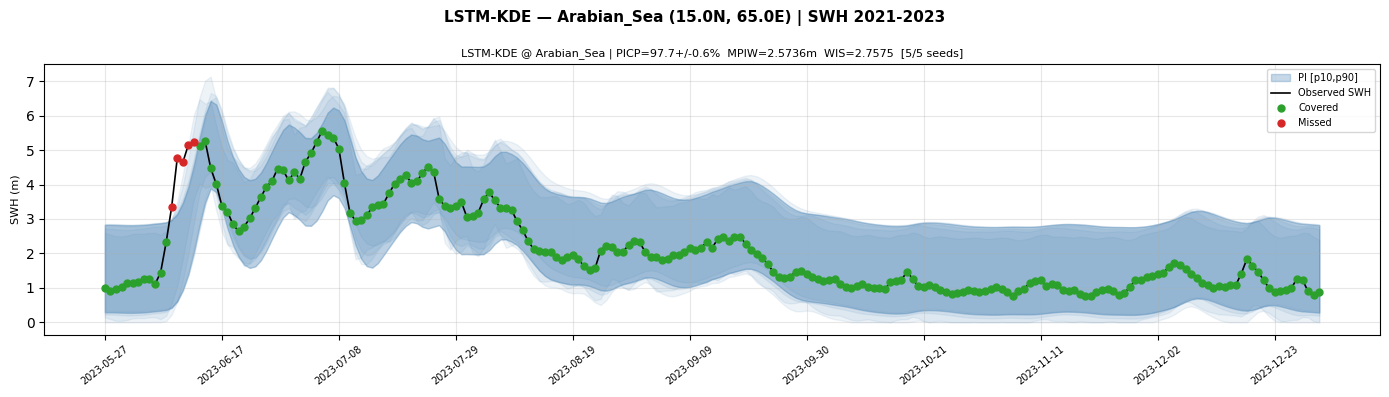

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes\results_SWH/plot_LSTM-KDE_Arabian_Sea_SWH.png


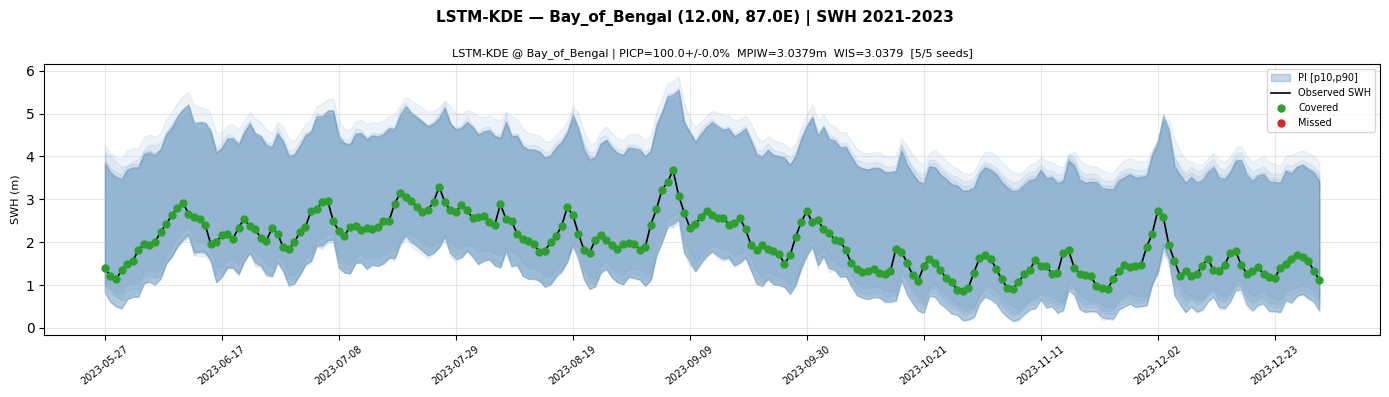

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes\results_SWH/plot_LSTM-KDE_Bay_of_Bengal_SWH.png


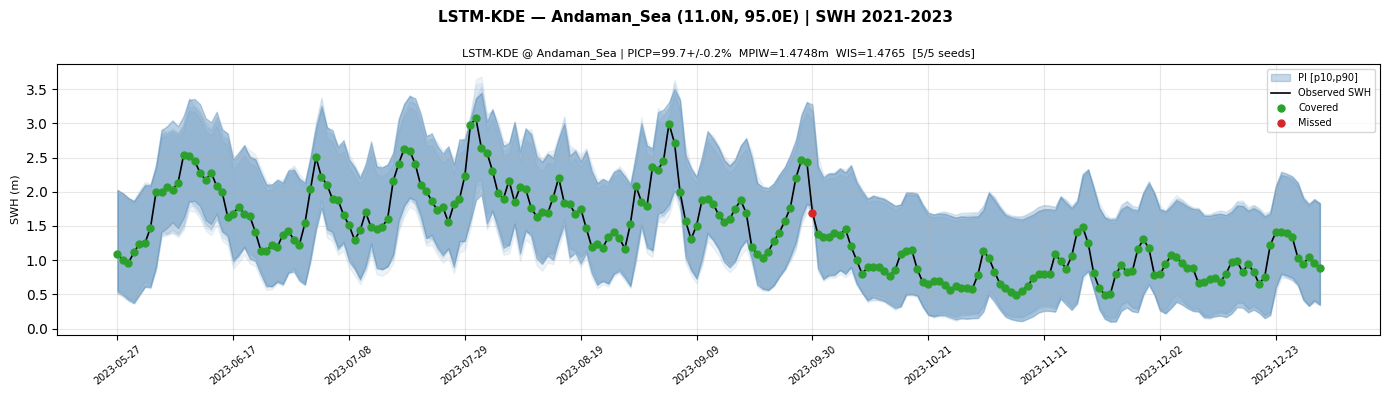

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes\results_SWH/plot_LSTM-KDE_Andaman_Sea_SWH.png


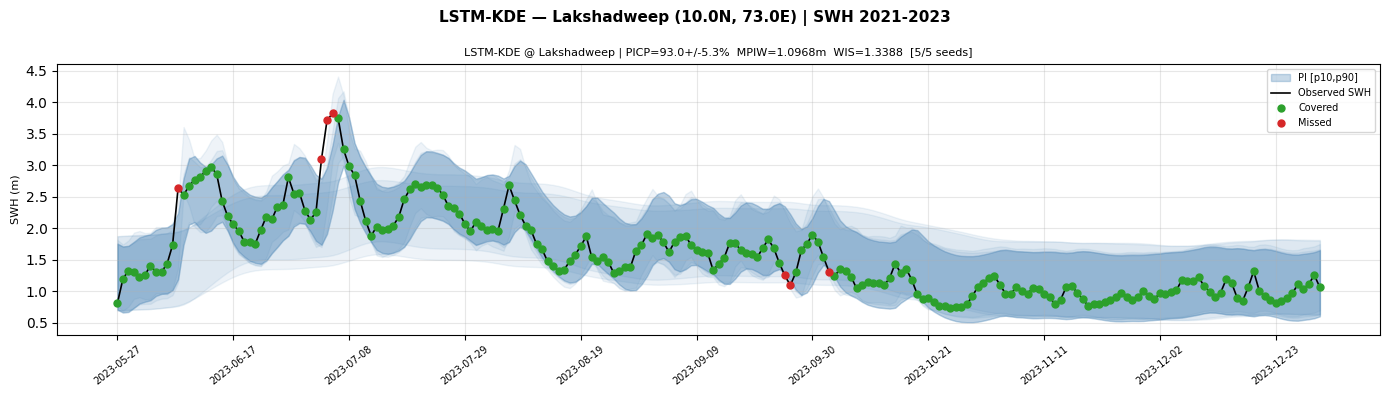

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes\results_SWH/plot_LSTM-KDE_Lakshadweep_SWH.png


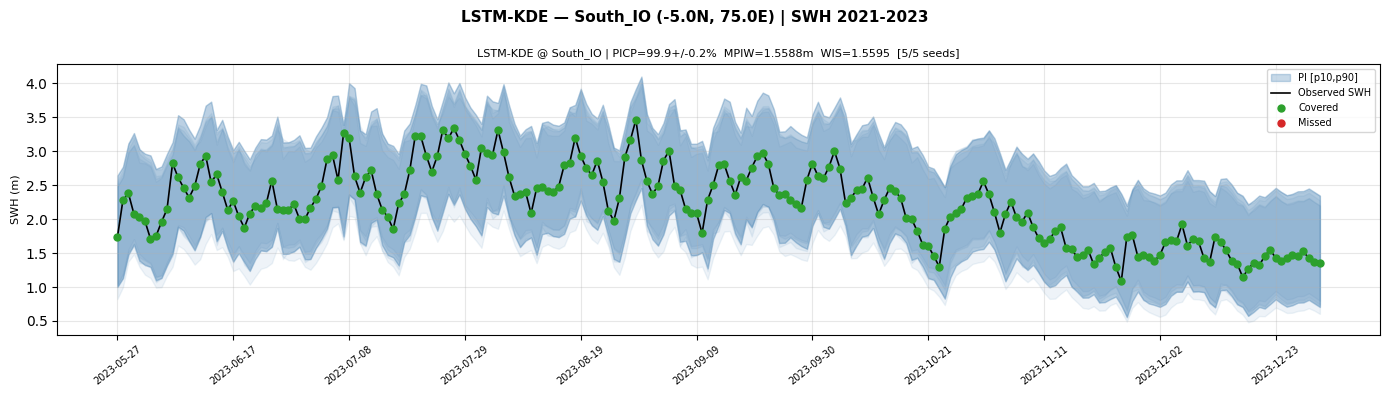

  Saved: c:\Users\DA IICT K\Desktop\BMP_files\SWH_codes\results_SWH/plot_LSTM-KDE_South_IO_SWH.png


In [10]:
# ── Cell 5: Visualisation ────────────────────────────────────
print('Generating plots...')
for loc_name in LOCATIONS:
    d   = get_splits(loc_name)
    lat, lon = LOCATIONS[loc_name]
    sub = df[df['location']==loc_name]
    n_rows = len(sub)
    fig, axes = plt.subplots(n_rows, 1, figsize=(14, 4*n_rows))
    if n_rows==1: axes=[axes]
    te_times = times_index[d['n_train']:]
    x_ax = range(len(te_times))
    step = max(1, len(te_times)//10)

    for ax, (_, row) in zip(axes, sub.iterrows()):
        mid = row['model']
        pd_ = all_preds.get(loc_name, {}).get(mid, {})
        y_m = None
        for seed, (lo,hi,ym) in pd_.items():
            if y_m is None: y_m = ym
            if np.any(np.isnan(lo)): continue
            ax.fill_between(x_ax, lo, hi, alpha=0.09, color='steelblue')
        cands = [(abs(np.mean((ym>=lo)&(ym<=hi))*100 - row['avg_picp']), seed)
                 for seed,(lo,hi,ym) in pd_.items() if not np.any(np.isnan(lo))]
        if cands:
            best = sorted(cands)[0][1]
            lo_b,hi_b,y_m = pd_[best]
            ax.fill_between(x_ax, lo_b, hi_b, alpha=0.30, color='steelblue', label='PI [p10,p90]')
            covered = (y_m >= lo_b) & (y_m <= hi_b)
            ax.plot(x_ax, y_m, 'k-', lw=1.2, label='Observed SWH')
            ax.scatter(np.where(covered)[0],  y_m[covered],  color='#2ca02c', s=25, zorder=5, label='Covered')
            ax.scatter(np.where(~covered)[0], y_m[~covered], color='#d62728', s=25, zorder=5, label='Missed')
        ax.set_xticks(list(x_ax)[::step])
        ax.set_xticklabels([te_times[i].strftime('%Y-%m-%d') for i in range(0,len(te_times),step)],
                           rotation=38, fontsize=7)
        ax.set_ylabel('SWH (m)', fontsize=8)
        ax.set_title(f'{mid} @ {loc_name} | PICP={row["avg_picp"]:.1f}+/-{row["std_picp"]:.1f}%  '
                     f'MPIW={row["avg_mpiw"]:.4f}m  WIS={row["avg_wis"]:.4f}  [{row["n_valid_seeds"]}/{row["n_seeds"]} seeds]',
                     fontsize=8)
        ax.legend(fontsize=7, loc='upper right'); ax.grid(alpha=0.3)
    fig.suptitle(f'{ARCH} — {loc_name} ({lat}N, {lon}E) | SWH 2021-2023', fontsize=11, fontweight='bold')
    plt.tight_layout()
    fp = os.path.join(SAVE_DIR, f'plot_{ARCH}_{loc_name}_SWH.png')
    plt.savefig(fp, dpi=110, bbox_inches='tight'); plt.show()
    print(f'  Saved: {fp}')

In [11]:
# ── Cell 6: Per-arch summary table ──────────────────────────
print(f'\n{"="*95}')
print(f'  {ARCH} — SWH RESULTS')
print(f'{"="*95}')
print(f'  {"Location":<18} {"Model":<24} {"PICP%":>7} {"+/-":>5} {"MPIW(m)":>9} {"+/-":>8} '
      f'{"WIS":>9} {"CWC":>9} {"Valid":>6}')
print(f'  {"-"*95}')

for _, r in df.sort_values(["location","model"]).iterrows():
    # Removed the lines calculating r_s and d_s since they aren't printed here anyway
    print(f'  {r["location"]:<18} {r["model"]:<24} '
          f'{r["avg_picp"]:7.1f} {r["std_picp"]:5.1f} '
          f'{r["avg_mpiw"]:9.4f} {r["std_mpiw"]:8.4f} '
          f'{r["avg_wis"]:9.4f} {r["avg_cwc"]:9.4f} '
          f'{r["n_valid_seeds"]:>3}/{r["n_seeds"]}')


  LSTM-KDE — SWH RESULTS
  Location           Model                      PICP%   +/-   MPIW(m)      +/-       WIS       CWC  Valid
  -----------------------------------------------------------------------------------------------
  Andaman_Sea        LSTM-KDE                    99.7   0.2    1.4748   0.0165    1.4765    1.4748   5/5
  Arabian_Sea        LSTM-KDE                    97.7   0.6    2.5736   0.0984    2.7575    2.5736   5/5
  Bay_of_Bengal      LSTM-KDE                   100.0   0.0    3.0379   0.0796    3.0379    3.0379   5/5
  Lakshadweep        LSTM-KDE                    93.0   5.3    1.0968   0.0655    1.3388   33.3498   5/5
  South_IO           LSTM-KDE                    99.9   0.2    1.5588   0.1120    1.5595    1.5588   5/5
